1. **Creating a Custom Dataset for your files**

    A custom Dataset class must implement three functions: __init__, __len__, and __getitem__. Take a look at this implementation; the SatelliteImageClassification images are stored in a directory img_dir, and their labels are stored separately in a CSV file annotations_file.

    ```
    __init__
    ```
    The \__init__ function is run once when instantiating the Dataset object. We initialize the annotations file, and both transforms


    ```
    __len__
    ```
    The \__len__ function returns the number of samples in our dataset.


    ```
    __getitem__
    ```
    The \__getitem__ function loads and returns a sample from the dataset at the given index idx. Based on the index, it identifies the image’s location on disk, converts that to a tensor using read_image, retrieves the corresponding label from the csv data in self.img_labels, calls the transform functions on them (if applicable), and returns the tensor image and corresponding label in a tuple.

In [1]:
from torch.utils.data import Dataset
from PIL import Image

import pandas as pd
import numpy as np
import os

class CustomImageDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None, target_transform=None):
        self.dataframe = pd.read_csv(annotations_file)
        self.classes = list(self.dataframe.columns[2:])
        self.img_dir = img_dir
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.dataframe.index)

    def __getitem__(self, idx):
        img_name = self.dataframe.loc[idx, 'Id']
        img_path = os.path.join(self.img_dir, img_name + '.jpg')
        label = self.dataframe.loc[idx, self.classes]

        # Load image
        image = Image.open(img_path).convert('RGB')

        # Convert to numpy
        label = np.array(label, dtype=np.float32)

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

    def get_class_name(self):
        return self.classes

    - Preparing your data for training with DataLoaders

In [2]:
import torchvision.transforms.v2 as transforms
import torch
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((425, 300)),
    transforms.ToImage(),  # Convert to image format
    transforms.ConvertImageDtype(torch.float32),  # Convert image dtype
    transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))])


trainset = CustomImageDataset(annotations_file='./Multi_Label_dataset/train_data.csv', img_dir='./Multi_Label_dataset', transform=transform)
trainloader = DataLoader(trainset, batch_size=4, shuffle=True)

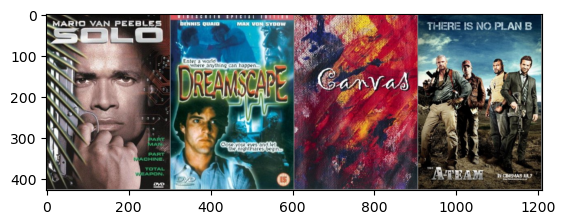

class: [['Action', 'Sci-Fi', 'Thriller'], ['Adventure', 'Sci-Fi', 'Thriller'], ['Animation', 'Short'], ['Action', 'Adventure', 'Comedy']]


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)


# show images
classes = np.array(trainset.classes)
imshow(torchvision.utils.make_grid(images))

# print labels
print(f'class: {[classes[np.where(labels[j]==1)].tolist() for j in range(4)]}')

2. Define a Convolutional Neural Network

In [4]:
from torchvision.models import resnet50, ResNet50_Weights
import torch.nn as nn

# New weights with accuracy 80.858%
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(2048, 25)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

3. Define a Loss function and optimizer

In [5]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

4. Train the network

In [6]:
torch.manual_seed(0)

# Check if GPU (cuda) is available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Move our model to device (GPU or CPU)
model.to(device)
model.train()

for epoch in range(5):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, (inputs, labels) in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = inputs.to(device), labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 1000 == 999:    # print every 1000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 1000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  1000] loss: 0.327
[2,  1000] loss: 0.234
[3,  1000] loss: 0.226
[4,  1000] loss: 0.220
[5,  1000] loss: 0.217
Finished Training


        - Save the model that we have trained

In [7]:
# Save model
torch.save(model.state_dict(), 'multi_classification_model.pt')